Using device: cuda
Found 25331 images.
Classes : {'AK': 0, 'BCC': 1, 'BKL': 2, 'DF': 3, 'MEL': 4, 'NV': 5, 'SCC': 6, 'VASC': 7}
Total   : 23257
Train: 18605 | Test: 4652
Pre-loading TRAIN images...


100%|██████████| 18605/18605 [08:09<00:00, 38.04it/s]


Train pre-load complete.
Val:3721 | Test:4652

✅ Partitions verified. Sizes: [5304, 11772, 1529]
  Client 0: [624, 2392, 1612, 10, 166, 463, 26, 11]
  Client 1: [35, 133, 90, 171, 2986, 8322, 25, 10]
  Client 2: [35, 133, 90, 10, 166, 462, 451, 182]

MAIN TRAINING — frac=0.9, rounds=20

RUNNING FEDAVG
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 170MB/s]


  Round 1/20 fedavg → val F1:0.5404
  Round 2/20 fedavg → val F1:0.6101
  Round 3/20 fedavg → val F1:0.6497
  Round 4/20 fedavg → val F1:0.7105
  Round 5/20 fedavg → val F1:0.7357
  Round 6/20 fedavg → val F1:0.7411
  Round 7/20 fedavg → val F1:0.7363
  Round 8/20 fedavg → val F1:0.8021
  Round 9/20 fedavg → val F1:0.7515
  Round 10/20 fedavg → val F1:0.7671
  Round 11/20 fedavg → val F1:0.7795
  Round 12/20 fedavg → val F1:0.7658
  Round 13/20 fedavg → val F1:0.7676
  Round 14/20 fedavg → val F1:0.7895
  Round 15/20 fedavg → val F1:0.7684
  Round 16/20 fedavg → val F1:0.7877
  Round 17/20 fedavg → val F1:0.8130
  Round 18/20 fedavg → val F1:0.7848
  Round 19/20 fedavg → val F1:0.7943
  Round 20/20 fedavg → val F1:0.8071
✅ fedavg → F1=0.5373  Acc=0.7182

RUNNING WEIGHTED_FEDAVG
  Round 1/20 weighted_fedavg → val F1:0.4696
  Round 2/20 weighted_fedavg → val F1:0.4665
  Round 3/20 weighted_fedavg → val F1:0.5159
  Round 4/20 weighted_fedavg → val F1:0.5300
  Round 5/20 weighted_fedavg → 

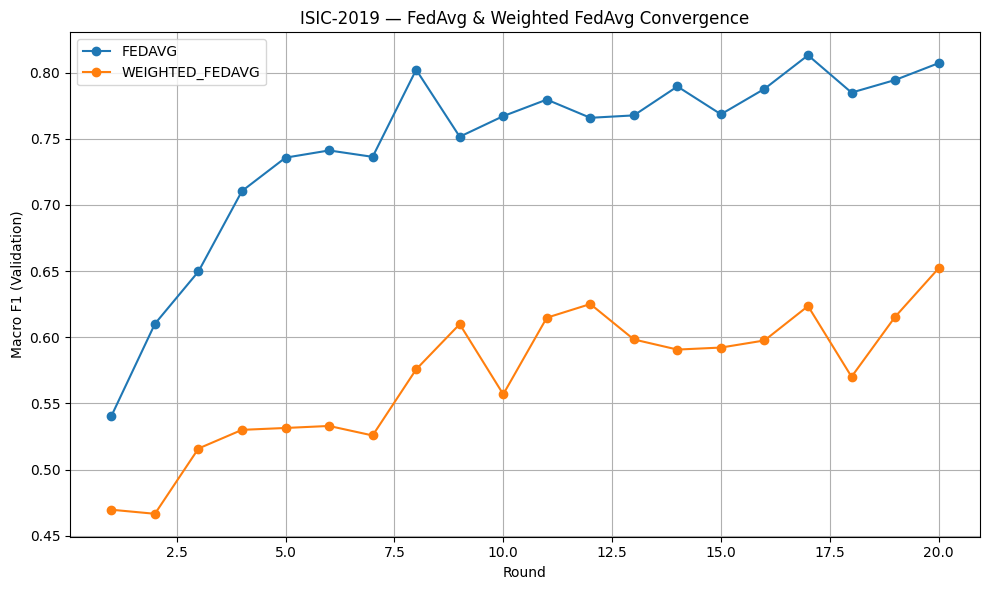


✅ Notebook 1A complete.
➡  Save output as: 'isic2019-fl-part-a'


In [1]:
# ==========================================
# NOTEBOOK 1A: ISIC-2019 FL TRAINING
# Methods: FedAvg + Weighted FedAvg
# Saves: models + checkpoints + shared assets
#        for Notebook 1B and Notebook 2
# ==========================================

!pip install -q kagglehub scikit-learn torchmetrics tqdm

import os, copy, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, balanced_accuracy_score
)
import matplotlib.pyplot as plt
from PIL import Image
from collections import OrderedDict
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 1. DATASET
# ==========================================
DATA_DIR = "/kaggle/input/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification"

csv_path = os.path.join(DATA_DIR, "ISIC_2019_Training_GroundTruth.csv")
df       = pd.read_csv(csv_path)

image_paths = {}
for cn in ['MEL','NV','BCC','AK','BKL','DF','VASC','SCC','UNK']:
    cd = os.path.join(DATA_DIR, cn)
    if not os.path.isdir(cd): continue
    for fname in os.listdir(cd):
        if fname.endswith('.jpg'):
            base = fname.replace('_downsampled.jpg','').replace('.jpg','')
            image_paths[base] = os.path.join(cd, fname)
print(f"Found {len(image_paths)} images.")

lesion_cols  = ['MEL','NV','BCC','AK','BKL','DF','VASC','SCC','UNK']
df['target'] = df[lesion_cols].idxmax(axis=1)
class_names  = sorted([c for c in df['target'].unique() if c != 'UNK'])
class_to_idx = {c: i for i, c in enumerate(class_names)}
df['label']  = df['target'].map(class_to_idx)
num_classes  = len(class_names)

df['image_base'] = df['image']
df = df[df['image_base'].isin(image_paths.keys())]
df = df[df['label'].notna()].reset_index(drop=True)
df['label'] = df['label'].astype(int)
print(f"Classes : {class_to_idx}")
print(f"Total   : {len(df)}")

# ==========================================
# 2. TRAIN / TEST SPLIT
# ==========================================
train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df['label'], random_state=42)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)
print(f"Train: {len(train_df)} | Test: {len(test_df)}")

# ==========================================
# 3. PRE-LOAD TRAIN INTO RAM
# ==========================================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

print("Pre-loading TRAIN images...")
train_tensors, train_labels = [], []
for _, row in tqdm(train_df.iterrows(), total=len(train_df)):
    try:
        img = Image.open(image_paths[row['image_base']]).convert("RGB")
        train_tensors.append(transform(img))
    except Exception:
        train_tensors.append(torch.zeros(3,224,224))
    train_labels.append(row['label'])
print("Train pre-load complete.")

# Test: streaming (saves RAM)
class StreamingDataset(Dataset):
    def __init__(self, df, image_paths, transform=None):
        self.df=df.reset_index(drop=True)
        self.image_paths=image_paths
        self.transform=transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row=self.df.iloc[idx]
        try:
            img=Image.open(self.image_paths[row['image_base']]).convert("RGB")
        except:
            img=Image.new("RGB",(224,224))
        if self.transform: img=self.transform(img)
        return img, int(row['label'])

test_dataset = StreamingDataset(test_df, image_paths, transform)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False,
                          num_workers=4, pin_memory=True)

class InMemoryDataset(Dataset):
    def __init__(self, images, labels, noise_level=0.0):
        self.images=images; self.labels=labels
        self.noise_level=noise_level
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        img=self.images[idx].clone()
        if self.noise_level>0:
            img+=torch.randn_like(img)*self.noise_level/255.0
            img=torch.clamp(img,0,1)
        return img, self.labels[idx]

val_idx    = np.random.RandomState(42).choice(
                 len(train_tensors), int(0.2*len(train_tensors)),
                 replace=False)
val_loader = DataLoader(
    InMemoryDataset([train_tensors[i] for i in val_idx],
                    [train_labels[i]  for i in val_idx]),
    batch_size=16, shuffle=False, num_workers=2, pin_memory=True)
print(f"Val:{len(val_idx)} | Test:{len(test_df)}")

# ==========================================
# 4. DISJOINT NON-IID SPLIT
# ==========================================
majority_classes_per_client = [[0,1,2],[3,4,5],[6,7]]

def disjoint_non_iid_split(labels, majority_per_client,
                            majority_frac=0.9, seed=42):
    np.random.seed(seed)
    labels_arr=np.array(labels)
    n_clients=len(majority_per_client)
    assigned=np.full(len(labels),-1,dtype=int)
    for class_id in range(num_classes):
        pos=np.where(labels_arr==class_id)[0].tolist()
        np.random.shuffle(pos)
        owner=next(
            (c for c,g in enumerate(majority_per_client) if class_id in g),0)
        n_maj=int(len(pos)*majority_frac)
        for i in pos[:n_maj]: assigned[i]=owner
        others=[c for c in range(n_clients) if c!=owner]
        for c,chunk in zip(others,
                np.array_split(pos[n_maj:],max(len(others),1))):
            for i in chunk: assigned[i]=c
    assigned[assigned==-1]=0
    for ci in range(n_clients):
        for cj in range(ci+1,n_clients):
            assert set(np.where(assigned==ci)[0]).isdisjoint(
                   set(np.where(assigned==cj)[0])), \
                   f"Overlap {ci} and {cj}!"
    return [np.where(assigned==c)[0].tolist() for c in range(n_clients)]

MAIN_FRAC      = 0.9
client_indices = disjoint_non_iid_split(
    train_labels, majority_classes_per_client, majority_frac=MAIN_FRAC)
client_sizes   = [len(idx) for idx in client_indices]

print(f"\n✅ Partitions verified. Sizes: {client_sizes}")
for i,idx in enumerate(client_indices):
    cl=[train_labels[j] for j in idx]
    print(f"  Client {i}: {np.bincount(cl,minlength=num_classes).tolist()}")

# ==========================================
# 5. CLASS WEIGHTS + DATALOADERS
# ==========================================
class_counts    = np.bincount(train_labels, minlength=num_classes)
class_weights_t = torch.tensor(
    1.0/class_counts/(1.0/class_counts).sum(),
    dtype=torch.float32).to(device)

NOISE_LEVELS = [0.0, 20.0, 10.0]

def get_dataloader(indices, noise_level=0.0, batch_size=16):
    imgs   = [train_tensors[i] for i in indices]
    lbls   = [train_labels[i]  for i in indices]
    ds     = InMemoryDataset(imgs, lbls, noise_level)
    counts = np.bincount(lbls, minlength=num_classes)
    sw     = 1.0/counts[lbls]; sw /= sw.sum()
    samp   = WeightedRandomSampler(sw, len(sw), replacement=True)
    return DataLoader(ds, batch_size=batch_size, sampler=samp,
                      num_workers=2, pin_memory=True)

dataloaders = [
    get_dataloader(client_indices[i], noise_level=NOISE_LEVELS[i])
    for i in range(3)
]

# ==========================================
# 6. MODEL + METRICS
# ==========================================
def get_model():
    m    = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m.to(device)

def compute_ece(y_prob, y_true, n_bins=15):
    try:
        from torchmetrics import CalibrationError
        calib=CalibrationError(task='multiclass',
                               num_classes=num_classes,
                               n_bins=n_bins,norm='l1')
        return calib(torch.tensor(y_prob),
                     torch.tensor(y_true)).item()
    except:
        pt=torch.tensor(y_prob); lt=torch.tensor(y_true)
        conf,pred=pt.max(dim=1); acc=pred.eq(lt)
        edges=torch.linspace(0,1,n_bins+1); ece=0.0
        for i in range(n_bins):
            mask=(conf>edges[i])&(conf<=edges[i+1])
            if mask.sum()>0:
                ece+=mask.sum().item()*abs(
                    acc[mask].float().mean().item()-
                    conf[mask].mean().item())
        return ece/max(len(y_true),1)

def evaluate_model(model, dataloader):
    model.eval()
    all_preds,all_labels=[],[]
    with torch.no_grad():
        for x,y in dataloader:
            x=x.to(device)
            preds=torch.argmax(F.softmax(model(x),dim=1),dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.numpy())
    y_true,y_pred=np.array(all_labels),np.array(all_preds)
    pc_acc,pc_rec=[],[]
    for c in range(num_classes):
        idx=y_true==c
        pc_acc.append(float(np.mean(y_pred[idx]==c)) if idx.sum()>0 else 0.0)
        tp=np.sum((y_pred==c)&(y_true==c))
        fn=np.sum((y_pred!=c)&(y_true==c))
        pc_rec.append(tp/(tp+fn) if (tp+fn)>0 else 0.0)
    return {
        'accuracy':           float(accuracy_score(y_true,y_pred)),
        'f1_macro':           float(f1_score(y_true,y_pred,
                                   average='macro',zero_division=0)),
        'f1_per_class':       f1_score(y_true,y_pred,
                                   average=None,zero_division=0).tolist(),
        'balanced_accuracy':  float(balanced_accuracy_score(y_true,y_pred)),
        'g_mean':             float(np.exp(np.mean(
                                   np.log([r+1e-8 for r in pc_rec])))),
        'per_class_accuracy': pc_acc,
        'y_true':             y_true.tolist(),
        'y_pred':             y_pred.tolist(),
    }

# ==========================================
# 7. LOCAL TRAINING + AGGREGATION
# ==========================================
MU = 0.001

def train_local(model, loader, gw,
                local_epochs=3, lr=1e-4,
                mu=0.0, ditto_lambda=0.0):
    model.train()
    opt  = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    crit = nn.CrossEntropyLoss(weight=class_weights_t)
    for _ in range(local_epochs):
        for x,y in loader:
            x,y=x.to(device),y.to(device)
            opt.zero_grad(); loss=crit(model(x),y)
            if mu>0:
                loss+=(mu/2)*sum(
                    torch.sum((p-gw[n].to(device))**2)
                    for n,p in model.named_parameters()
                    if n in gw and p.dtype.is_floating_point)
            if ditto_lambda>0:
                loss+=ditto_lambda*sum(
                    torch.sum((p-gw[n].to(device))**2)
                    for n,p in model.named_parameters()
                    if n in gw and p.dtype.is_floating_point)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
            opt.step()
    return {k:v.cpu().clone() for k,v in model.state_dict().items()}

def fedavg_agg(lw):
    avg=OrderedDict()
    for k in lw[0]:
        t=[w[k] for w in lw]
        avg[k]=torch.stack(t).mean(0) \
               if t[0].dtype.is_floating_point else t[0].clone()
    return avg

def weighted_fedavg_agg(lw, sizes):
    total=sum(sizes); avg=OrderedDict()
    for k in lw[0]:
        t=[w[k] for w in lw]
        avg[k]=sum(w[k]*(s/total) for w,s in zip(lw,sizes)) \
               if t[0].dtype.is_floating_point else t[0].clone()
    return avg

# ==========================================
# 8. FL RUNNER
# ==========================================
CHECKPOINT_ROUNDS = [1, 5, 10, 15, 20]

def run_fl(name, dataloaders, client_sizes,
           rounds=20, local_epochs=3, lr=1e-4,
           save_clients=True,
           checkpoint_rounds=CHECKPOINT_ROUNDS):
    gm  = get_model()
    gw  = {k:v.cpu() for k,v in gm.state_dict().items()}
    cms = [get_model() for _ in range(3)]
    pw  = [{k:v.cpu().clone() for k,v in gm.state_dict().items()}
           for _ in range(3)]
    best_f1,best_gw=-1.0,None
    history=[]

    for rnd in range(rounds):
        if name=='ditto':
            gl=[]
            for cid,loader in enumerate(dataloaders):
                tmp=get_model(); tmp.load_state_dict(gw,strict=True)
                gl.append(train_local(tmp,loader,gw,
                                      local_epochs=local_epochs,lr=lr))
            gw=fedavg_agg(gl); gm.load_state_dict(gw,strict=True)
            for cid,loader in enumerate(dataloaders):
                cms[cid].load_state_dict(pw[cid],strict=True)
                pw[cid]=train_local(cms[cid],loader,gw,
                                    local_epochs=local_epochs,lr=lr,
                                    ditto_lambda=0.005)
        else:
            lw=[]
            for cid,loader in enumerate(dataloaders):
                cms[cid].load_state_dict(gw,strict=True)
                lw.append(train_local(cms[cid],loader,gw,
                                      local_epochs=local_epochs,lr=lr,
                                      mu=(MU if name=='fedprox' else 0.0)))
            if   name=='fedavg':
                gw=fedavg_agg(lw)
            elif name=='weighted_fedavg':
                gw=weighted_fedavg_agg(lw,client_sizes)
            gm.load_state_dict(gw,strict=True)

        val_m=evaluate_model(gm,val_loader)
        history.append({'round':rnd,'aggregation':name,
                        'f1_macro':val_m['f1_macro'],
                        'accuracy':val_m['accuracy'],
                        'balanced_acc':val_m['balanced_accuracy'],
                        'g_mean':val_m['g_mean']})
        print(f"  Round {rnd+1}/{rounds} {name} → "
              f"val F1:{val_m['f1_macro']:.4f}")

        if val_m['f1_macro']>best_f1:
            best_f1=val_m['f1_macro']
            best_gw=copy.deepcopy(gw)

        if (rnd+1) in checkpoint_rounds:
            ckpt=get_model(); ckpt.load_state_dict(gw,strict=True)
            torch.save(ckpt.state_dict(),
                       f"/kaggle/working/ckpt_{name}_round{rnd+1}.pth")

    gm.load_state_dict(best_gw,strict=True)

    if save_clients:
        for cid in range(3):
            sm=get_model()
            sm.load_state_dict(
                pw[cid] if name=='ditto'
                else cms[cid].state_dict(),strict=True)
            torch.save(sm.state_dict(),
                       f"/kaggle/working/client_{name}_{cid}.pth")

    fm=evaluate_model(gm,test_loader)
    return history,gm,cms,fm

# ==========================================
# 9. MAIN RUN — FedAvg + Weighted FedAvg
# ==========================================
ROUNDS       = 20
LOCAL_EPOCHS = 3
LR           = 1e-4
METHODS      = ['fedavg','weighted_fedavg']

print(f"\n{'='*60}")
print(f"MAIN TRAINING — frac={MAIN_FRAC}, rounds={ROUNDS}")
print(f"{'='*60}")

all_history  = []
final_models = {}
final_metrics= {}

for name in METHODS:
    print(f"\n{'='*50}\nRUNNING {name.upper()}\n{'='*50}")
    hist,gm,cms,fm=run_fl(
        name,dataloaders,client_sizes,
        rounds=ROUNDS,local_epochs=LOCAL_EPOCHS,lr=LR,
        save_clients=True,checkpoint_rounds=CHECKPOINT_ROUNDS)
    for rec in hist: all_history.append(rec)
    final_models[name]=gm; final_metrics[name]=fm
    torch.save(gm.state_dict(),
               f"/kaggle/working/final_model_{name}.pth")
    print(f"✅ {name} → F1={fm['f1_macro']:.4f}  "
          f"Acc={fm['accuracy']:.4f}")

# ==========================================
# 10. ABLATION — FedAvg + Weighted FedAvg
# ==========================================
ABLATION_ROUNDS=10; ABLATION_FRACS=[0.5,0.7]

print(f"\n{'='*60}\nABLATION\n{'='*60}")

ablation_results=[]
for name in METHODS:
    m=final_metrics[name]
    ablation_results.append({'majority_frac':MAIN_FRAC,'method':name,
                             'accuracy':m['accuracy'],
                             'f1_macro':m['f1_macro'],
                             'g_mean':m['g_mean'],
                             'balanced_acc':m['balanced_accuracy']})

for frac in ABLATION_FRACS:
    print(f"\n--- frac={frac} ---")
    ai=disjoint_non_iid_split(train_labels,majority_classes_per_client,
                               majority_frac=frac)
    al=[get_dataloader(ai[i],noise_level=NOISE_LEVELS[i])
        for i in range(3)]
    asz=[len(i) for i in ai]
    for name in METHODS:
        _,gm,_,fm=run_fl(name,al,asz,rounds=ABLATION_ROUNDS,
                         local_epochs=LOCAL_EPOCHS,lr=LR,
                         save_clients=False,checkpoint_rounds=[])
        ablation_results.append({'majority_frac':frac,'method':name,
                                 'accuracy':fm['accuracy'],
                                 'f1_macro':fm['f1_macro'],
                                 'g_mean':fm['g_mean'],
                                 'balanced_acc':fm['balanced_accuracy']})
        print(f"  ✅ {name} frac={frac} → F1={fm['f1_macro']:.4f}")

# ==========================================
# 11. SAVE ALL ARTIFACTS
# ==========================================
import shutil

pd.DataFrame(all_history).to_csv(
    "/kaggle/working/fl_results_part_a.csv",index=False)
pd.DataFrame(ablation_results).to_csv(
    "/kaggle/working/ablation_part_a.csv",index=False)
test_df.to_csv("/kaggle/working/test_df.csv",index=False)
train_df.to_csv("/kaggle/working/train_df.csv",index=False)

for cid,idx in enumerate(client_indices):
    cdf=train_df.iloc[idx].reset_index(drop=True)
    cdf.to_csv(f"/kaggle/working/client_{cid}_train.csv",index=False)
    _,cdf_test=train_test_split(
        cdf,test_size=0.2,random_state=42,
        stratify=cdf['label'] if cdf['label'].nunique()>1 else None)
    cdf_test.to_csv(
        f"/kaggle/working/client_{cid}_test_split.csv",index=False)

with open("/kaggle/working/meta.json","w") as f:
    json.dump({'class_to_idx':class_to_idx,
               'class_names':class_names,
               'majority_classes_per_client':majority_classes_per_client,
               'client_sizes':client_sizes,
               'checkpoint_rounds':CHECKPOINT_ROUNDS,
               'main_frac':MAIN_FRAC},f)

# Convergence plot Part A
df_h=pd.DataFrame(all_history)
plt.figure(figsize=(10,6))
colors={'fedavg':'#1f77b4','weighted_fedavg':'#ff7f0e'}
for name in METHODS:
    sub=df_h[df_h['aggregation']==name]
    plt.plot(sub['round']+1,sub['f1_macro'],
             marker='o',color=colors[name],label=name.upper())
plt.xlabel('Round'); plt.ylabel('Macro F1 (Validation)')
plt.title('ISIC-2019 — FedAvg & Weighted FedAvg Convergence')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig("/kaggle/working/convergence_part_a.png",dpi=150)
plt.show()

print("\n✅ Notebook 1A complete.")
print("➡  Save output as: 'isic2019-fl-part-a'")